<font color = 'blue'>

# INTRODUCTION 

The dataset under consideration consists of a total of 7,909 histopathological breast tissue biopsy images, annotated by expert pathologists. The images were obtained from hematoxylin and eosin (H&E) stained slides and encompass eight distinct tumor classes: benign (Adenosis, Fibroadenoma, Tubular Adenoma, Phyllodes Tumor) and malignant (Ductal, Lobular, Mucinous, Papillary Carcinoma). The dataset exhibits an imbalanced class distribution, with the majority of samples belonging to the Ductal Carcinoma class (3,451 instances), indicating its inherently imbalanced nature. The objective of this study is to develop a machine learning model capable of automatically classifying tumor types from these histopathological images.

<font  color = 'purple'>
Content:
    
1. [Load and Check Data](#1)
2. [Sample Visualization](#2)
3. [Outlier Detection](#3)
4. [Missing Values](#4)

<font color = 'red'>
    
<a id ="1"></a>

## Load and Check Data
<font color = 'black'>

In this section, we import the necessary libraries.

In [2]:
import pandas as pd
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from collections import Counter
from PIL import Image
import random
from sklearn.model_selection import train_test_split , StratifiedKFold
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

A for loop was used to display sample images from the dataset in order to visually examine the data and confirm correct labeling.

In [3]:
root_dir = "BreaKHis_v1/histology_slides/breast"

image_paths = []
labels = []

for class_folder in ["benign", "malignant"]:
    class_path = os.path.join(root_dir, class_folder)
    
    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(".png"):
                tumor_type = file.split("-")[0]  # A, F, PT, TA, DC, LC, MC, PC
                
                image_paths.append(os.path.join(root, file))
                labels.append(tumor_type)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))
print(df["label"].value_counts())

Total images: 7909
label
SOB_M_DC    3451
SOB_B_F     1014
SOB_M_MC     792
SOB_M_LC     626
SOB_B_TA     569
SOB_M_PC     560
SOB_B_PT     453
SOB_B_A      444
Name: count, dtype: int64


In [4]:
df.head()

,image_path,label
0,BreaKHis_v1/histology_slides/breast\benign\SOB...,SOB_B_A
1,BreaKHis_v1/histology_slides/breast\benign\SOB...,SOB_B_A
2,BreaKHis_v1/histology_slides/breast\benign\SOB...,SOB_B_A
3,BreaKHis_v1/histology_slides/breast\benign\SOB...,SOB_B_A
4,BreaKHis_v1/histology_slides/breast\benign\SOB...,SOB_B_A


The first five samples of the dataset were examined to verify the correctness of the labels.

In [5]:
df.describe()

,image_path,label
count,7909,7909
unique,7909,8
top,BreaKHis_v1/histology_slides/breast\benign\SOB...,SOB_M_DC
freq,1,3451


The summary statistics indicate that the dataset contains 7,909 unique images distributed across 8 classes, with Ductal Carcinoma (SOB_M_DC) being the most frequent class (3,451 samples), confirming a class imbalance in the dataset.

<font color = 'red'>
<a id ="2"></a>


## Sample Visualization

We briefly reviewed the basic features of each group for a better understanding:

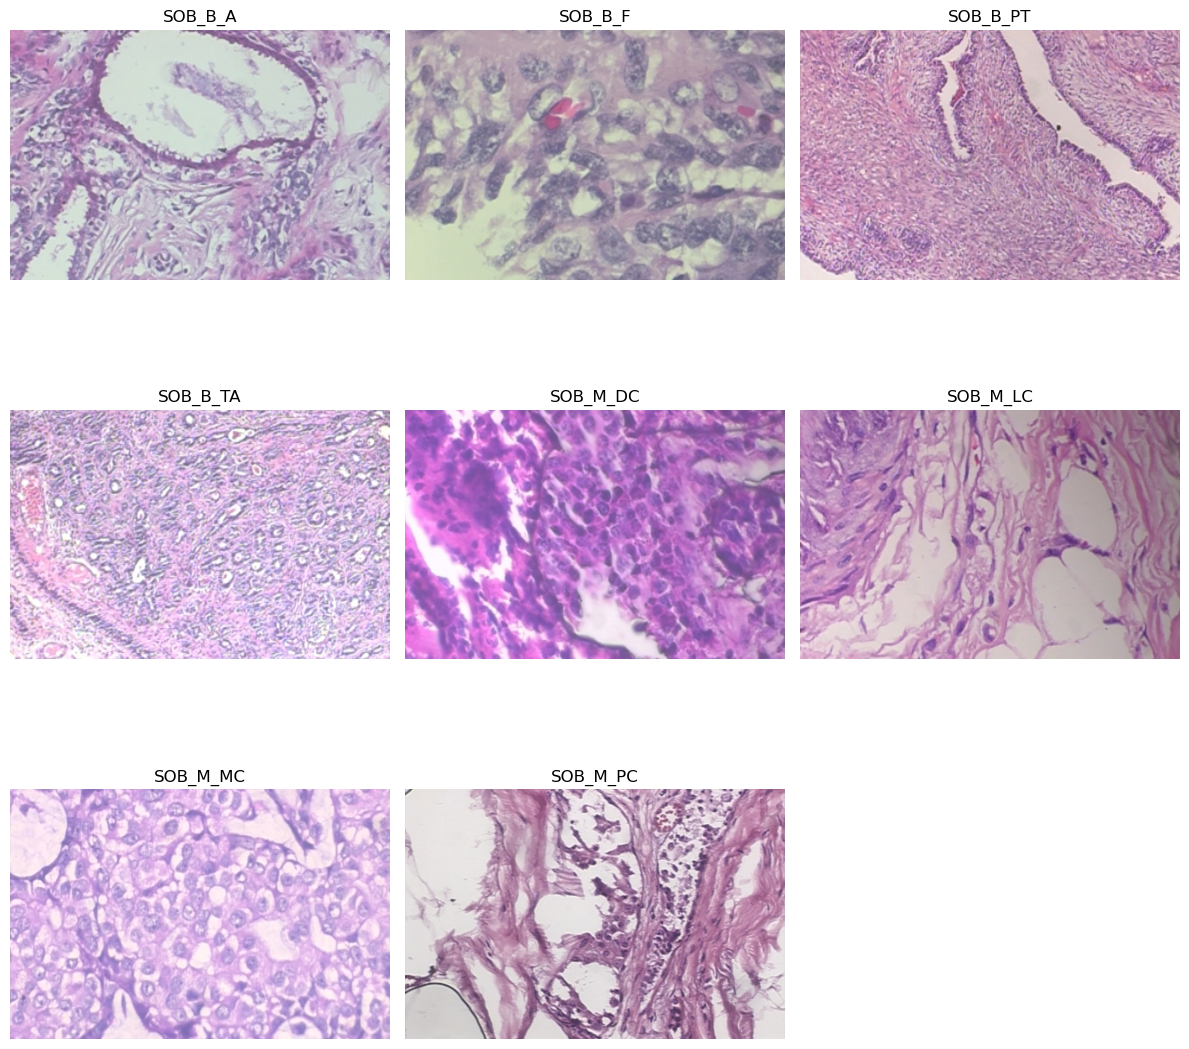

In [7]:
classes = df['label'].unique()

plt.figure(figsize=(12, 12))

i = 1
for cls in classes:
    sample = df[df['label'] == cls].sample(1).iloc[0]
    img = Image.open(sample['image_path'])
    
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
    i += 1

plt.tight_layout()
plt.show()

To better understand the structural diversity of the dataset, a sample grid of the 8 distinct tumor subclasses is visualized above. The dataset is primarily divided into two main categories: Benign and Malignant tumors, which are further classified into four sub-types each.

1. Benign Tumors:
* Adenosis (SOB_B_A): Characterized by the enlargement of the breast lobules. The images typically display circular, enlarged glandular structures.
* Fibroadenoma (SOB_B_F): The most common type of benign breast tumor, comprising both glandular and connective tissue. It often presents with dense cellular structures and cleft-like spaces.
* Phyllodes Tumor (SOB_B_PT): Distinguished by its "leaf-like" architectural growth pattern, featuring elongated spaces and dense cellular stroma.
* Tubular Adenoma (SOB_B_TA): Visually identifiable by tightly packed, small tubular structures that are prominent throughout the tissue sample.

2. Malignant Tumors:
* Ductal Carcinoma (SOB_M_DC): The most common type of breast cancer, originating in the milk ducts. Histologically, it presents highly irregular, enlarged, and prominent cell nuclei.
* Lobular Carcinoma (SOB_M_LC): Originating in the milk glands (lobules), these cells are frequently observed arranged in single-file lines (often referred to as an "Indian file" pattern) or as scattered, irregular clusters.
* Mucinous Carcinoma (SOB_M_MC): Easily identifiable by the presence of tumor cells floating within large, extracellular pools of mucin. These mucin pools appear as broad, pale, or clear areas in the images.
* Papillary Carcinoma (SOB_M_PC): Characterized by finger-like (papillary) cellular projections and fronds forming within the tissue structure.

<font color = 'red'>
<a id ="3"></a>


## Outlier Detection

We focuse on structural inconsistencies rather than extreme numerical values. This involves checking for anomalous image dimensions or unexpected color channels. 

In [8]:
print("Checking for Outliers...")

unique_shapes = set()
unique_modes = set()

for path in tqdm(df["image_path"], desc="Scanning Dimensions & Modes"):
    try:
        with Image.open(path) as img:
            unique_shapes.add(img.size)
            unique_modes.add(img.mode)
    except Exception:
        pass

print(f"\nUnique Image Shapes (Shape Outliers): {unique_shapes}")
print(f"Unique Color Modes (Channel Outliers): {unique_modes}")


Checking for Outliers...


Scanning Dimensions & Modes: 100%|██████████| 7909/7909 [00:12<00:00, 623.55it/s]


Unique Image Shapes (Shape Outliers): {(700, 460), (700, 456)}
Unique Color Modes (Channel Outliers): {'RGB'}


The structural analysis revealed that all 7,909 images consistently utilize the standard RGB color space, meaning there are no channel outliers. However, a minor dimensional variance was detected; image shapes were observed to be either 700x460 or 700x456 pixels. Since CNN architectures require strictly uniform input matrices, identifying this discrepancy is critical. To resolve this and optimize computational resources, all images will be resized to an uniform dimension during the data preprocessing pipeline.

<font color = 'red'>
<a id ="4"></a>


## Missing Values

A thorough data integrity check was performed to verify that every image path points to a valid, decodable image file.

In [9]:
print("Checking for Missing/Corrupted Values...")

corrupted_files = []

for path in tqdm(df["image_path"], desc="Verifying Image Integrity"):
    try:
        with Image.open(path) as img:
            img.verify() 
    except Exception as e:
        corrupted_files.append((path, str(e)))

print(f"\nTotal Corrupted/Missing Files: {len(corrupted_files)}")

if len(corrupted_files) > 0:
    print("Sample corrupted files:")
    for file, error in corrupted_files[:5]:
        print(f" - {file} (Error: {error})")

Checking for Missing/Corrupted Values...


Verifying Image Integrity: 100%|██████████| 7909/7909 [00:29<00:00, 271.87it/s]


Total Corrupted/Missing Files: 0


The process yielded 0 missing or corrupted files, confirming that the entire dataset is readable, and ready for the preprocessing pipeline.

<font color = 'blue'>

# DEEP LEARNING MODELS

<font  color = 'purple'>
Content:
    
1. [Data Preparation](#5)
2. [CNN Models](#6)
   * [Baseline Model](#9)
   * [Improved Model](#10)
   * [GAP Model](#11)
3. [DenseNet121 Models](#7)
4. [Conclusion](#8)

<font color = 'red'>
<a id ="5"></a>


## Data Preparation

<font color = 'green'>

* Train-Cross Validation-Test Split

In [6]:
df_train_val, df_test = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)

df_train_val = df_train_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("--- Dataset Splitting Results ---")
print(f"Total Dataset Size: {len(df)}")
print(f"Train & Val: {len(df_train_val)} images")
print(f"Isolated Test Set: {len(df_test)} images")

print("\nApplying 5-Fold Stratified Cross-Validation to the Working Set...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize a 'fold' column with -1
df_train_val['fold'] = -1

for fold_no, (train_idx, val_idx) in enumerate(skf.split(df_train_val['image_path'], df_train_val['label'])):
    df_train_val.loc[val_idx, 'fold'] = fold_no

print("Images per fold:")
print(df_train_val['fold'].value_counts().sort_index())

--- Dataset Splitting Results ---
Total Dataset Size: 7909
Train & Val: 6327 images
Isolated Test Set: 1582 images

Applying 5-Fold Stratified Cross-Validation to the Working Set...
Images per fold:
fold
0    1266
1    1266
2    1265
3    1265
4    1265
Name: count, dtype: int64


The dataset was divided into a working set (80%) for training and validation, and an isolated test set (20%) for final evaluation. The stratify parameter was used to maintain the original benign-to-malignant class ratio across all splits. To ensure a robust model evaluation and prevent overfitting, a 5-Fold Stratified Cross-Validation was applied to the 80% working set.

<font color = 'green'>

* Resize the images

In [11]:
train_val_datagen = ImageDataGenerator(rescale=1./255.)

test_datagen = ImageDataGenerator(rescale=1./255.)


TARGET_SIZE = (224, 224) 
BATCH_SIZE = 32 

# Test setini baştan hazır edip kenara koyalım
print("\nPreparing Isolated Test Set Generator:")
test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col="image_path",
    y_col="label",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False 
)


Preparing Isolated Test Set Generator:
Found 1582 validated image filenames belonging to 8 classes.


To ensure compatibility with the Convolutional Neural Network (CNN) architecture and to resolve the dimensional inconsistencies found in the dataset (700x460 vs. 700x456), all images were dynamically resized to a standard dimension of 224x224 pixels

<font color = 'red'>
<a id ="6"></a>


## CNN Models

<font color = 'green'>
<a id ="9"></a>

* ### Baseline Model

To establish a baseline and understand the BreaKHis dataset's structure, a fundamental Convolutional Neural Network (CNN) was developed. The architecture features three sequential convolutional blocks, each utilizing Batch Normalization for training stability and MaxPooling for spatial dimensionality reduction. The extracted feature maps are then transformed via a Flatten layer and passed into a 256-neuron fully connected Dense layer. To mitigate overfitting, a 50% Dropout rate is applied before the final 8-neuron softmax output layer, which classifies the tissue types using the Adam optimizer and categorical crossentropy loss.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

def create_model():
    
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
        BatchNormalization(), 
        MaxPooling2D(2, 2),   

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(), 
        
        Dense(256, activation='relu'), 
        Dropout(0.5),
        Dense(8, activation='softmax') 
    ])

    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy']) 
                  
    return model

model = create_model()
model.summary()

c:\Users\avcie\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,247,624 (84.87 MB)

 Trainable params: 22,247,176 (84.87 MB)

 Non-trainable params: 448 (1.75 KB)

* #### Class Weight

Since the class distribution in the dataset was imbalanced, class weights were calculated using the compute_class_weight function by considering the number of samples in each class. These weights were later used during the training of the CNN models so that underrepresented classes could have a stronger influence on the learning process. In this way, a solution was applied to reduce the negative impact of class imbalance on model performance.

In [12]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = df_train_val['label'].values

unique_classes = np.sort(np.unique(train_labels))

weights = compute_class_weight(class_weight='balanced', 
                               classes=unique_classes, 
                               y=train_labels)

class_weights_dict = dict(enumerate(weights))

print(class_weights_dict)

{0: np.float64(2.227816901408451), 1: np.float64(0.9751849568434032), 2: np.float64(2.1847375690607733), 3: np.float64(1.7381868131868132), 4: np.float64(0.2864451285766027), 5: np.float64(1.5785928143712575), 6: np.float64(1.2474369085173502), 7: np.float64(1.7653459821428572)}


* Model Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 15 

fold_histories = [] 

for fold in range(5):
    print(f"\n{'='*50}\n FOLD {fold+1} EĞİTİMİ BAŞLIYOR\n{'='*50}")

    
    train_df = df_train_val[df_train_val['fold'] != fold]
    val_df = df_train_val[df_train_val['fold'] == fold]

  
    train_datagen = ImageDataGenerator(
        rescale=1./255.,
        rotation_range=20,     
        horizontal_flip=True,   
        vertical_flip=True      
    )

    val_datagen = ImageDataGenerator(rescale=1./255.)

    print(f"Fold {fold+1} - Training Set:")
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="image_path",
        y_col="label",
        target_size=TARGET_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True 
    )

    print(f"Fold {fold+1} - Validation Set:")
    val_generator = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="image_path",
        y_col="label",
        target_size=TARGET_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False 
    )


    model = create_model()

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=val_generator,
        class_weight=class_weights_dict, 
        callbacks=[early_stop],
        verbose=1
    )

    fold_histories.append(history)
    print(f"\n Fold {fold+1} Egitimi basariyla tamamlandi.")

print("\n TÜM 5 FOLD İÇİN ÇAPRAZ DOĞRULAMA (CROSS-VALIDATION) BİTTİ!")


🚀 FOLD 1 EĞİTİMİ BAŞLIYOR
Fold 1 - Training Set:
Found 5061 validated image filenames belonging to 8 classes.
Fold 1 - Validation Set:
Found 1266 validated image filenames belonging to 8 classes.


c:\Users\avcie\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.1861 - loss: 17.5132 - val_accuracy: 0.4265 - val_loss: 16.5520
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.0863 - loss: 2.1012 - val_accuracy: 0.0956 - val_loss: 2.0867
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.0915 - loss: 2.0867 - val_accuracy: 0.1532 - val_loss: 3.6423
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.0915 - loss: 2.0739 - val_accuracy: 0.1690 - val_loss: 1.9611
Epoch 5/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.0952 - loss: 2.0736 - val_accuracy: 0.0877 - val_loss: 1.9983
Epoch 6/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.1037 - loss: 2.0545 - val_accuracy: 0.2006 - val_loss: 2.3354
Epoch 7/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.1330 - loss: 2.0550 - val_accuracy: 0.1975 - val_loss: 1.8981
Epoch 8/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.1150 - loss: 2.0759 - val_ac

c:\Users\avcie\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.1743 - loss: 13.6508 - val_accuracy: 0.4210 - val_loss: 7.6969
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.0703 - loss: 2.0862 - val_accuracy: 0.0648 - val_loss: 2.0942
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.0692 - loss: 2.0753 - val_accuracy: 0.0616 - val_loss: 2.0703
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.0561 - loss: 2.0803 - val_accuracy: 0.0616 - val_loss: 2.0847
Epoch 5/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.0613 - loss: 2.1010 - val_accuracy: 0.2599 - val_loss: 2.2888
Epoch 6/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.0871 - loss: 2.1625 - val_accuracy: 0.0735 - val_loss: 2.0644
Epoch 7/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.0822 - loss: 2.1123 - val_accuracy: 0.0632 - val_loss: 2.0964
Epoch 8/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.0697 - loss: 2.0965 - val_acc

...

Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.1650 - loss: 11.7903 - val_accuracy: 0.1968 - val_loss: 8.2936
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.1152 - loss: 2.0885 - val_accuracy: 0.2893 - val_loss: 3.1223
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.1118 - loss: 2.0796 - val_accuracy: 0.1510 - val_loss: 2.0267
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 358s 2s/step - accuracy: 0.1081 - loss: 2.0986 - val_accuracy: 0.4000 - val_loss: 6.1956
Epoch 5/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.1015 - loss: 2.0742 - val_accuracy: 0.2364 - val_loss: 2.0963
Epoch 6/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.0836 - loss: 2.0754 - val_accuracy: 0.1842 - val_loss: 2.0814
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

✅ Fold 3 Eğitimi Başarıyla Tamamlandı!

🚀 FOLD 4 EĞİTİMİ BAŞLIYOR
Fold 4 - Training Set:
Found 5062 validated image filenames belonging to 8 

c:\Users\avcie\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.1557 - loss: 11.4059 - val_accuracy: 0.0791 - val_loss: 20.3804
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.0701 - loss: 2.0919 - val_accuracy: 0.2538 - val_loss: 2.5812
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.0668 - loss: 2.1185 - val_accuracy: 0.1336 - val_loss: 2.2269
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.0792 - loss: 2.0981 - val_accuracy: 0.0893 - val_loss: 2.0583
Epoch 5/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.0658 - loss: 2.1073 - val_accuracy: 0.0561 - val_loss: 2.0849
Epoch 6/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.0652 - loss: 2.0907 - val_accuracy: 0.3036 - val_loss: 5.3231
Epoch 7/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.0687 - loss: 2.0827 - val_accuracy: 0.0735 - val_loss: 2.0586
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.

✅ Fold 4 Eğ

c:\Users\avcie\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.1827 - loss: 12.1607 - val_accuracy: 0.0901 - val_loss: 18.4689
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.0891 - loss: 2.0977 - val_accuracy: 0.3257 - val_loss: 4.3952
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.0948 - loss: 2.0849 - val_accuracy: 0.0854 - val_loss: 2.0599
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.0822 - loss: 2.0869 - val_accuracy: 0.0727 - val_loss: 2.0797
Epoch 5/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.0861 - loss: 2.1472 - val_accuracy: 0.0704 - val_loss: 2.4849
Epoch 6/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.0589 - loss: 2.0907 - val_accuracy: 0.1344 - val_loss: 2.0098
Epoch 7/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.0847 - loss: 2.0745 - val_accuracy: 0.2166 - val_loss: 1.9722
Epoch 8/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.0865 - loss: 2.0801 - val_ac

* Accuracy-Loss Graphs

Fold 1 - En İyi Val Accuracy: %42.65
Fold 2 - En İyi Val Accuracy: %42.10
Fold 3 - En İyi Val Accuracy: %40.00
Fold 4 - En İyi Val Accuracy: %30.36
Fold 5 - En İyi Val Accuracy: %32.57

Genel Ortalama Doğruluk (Mean CV Accuracy): %37.54 (± %5.09)


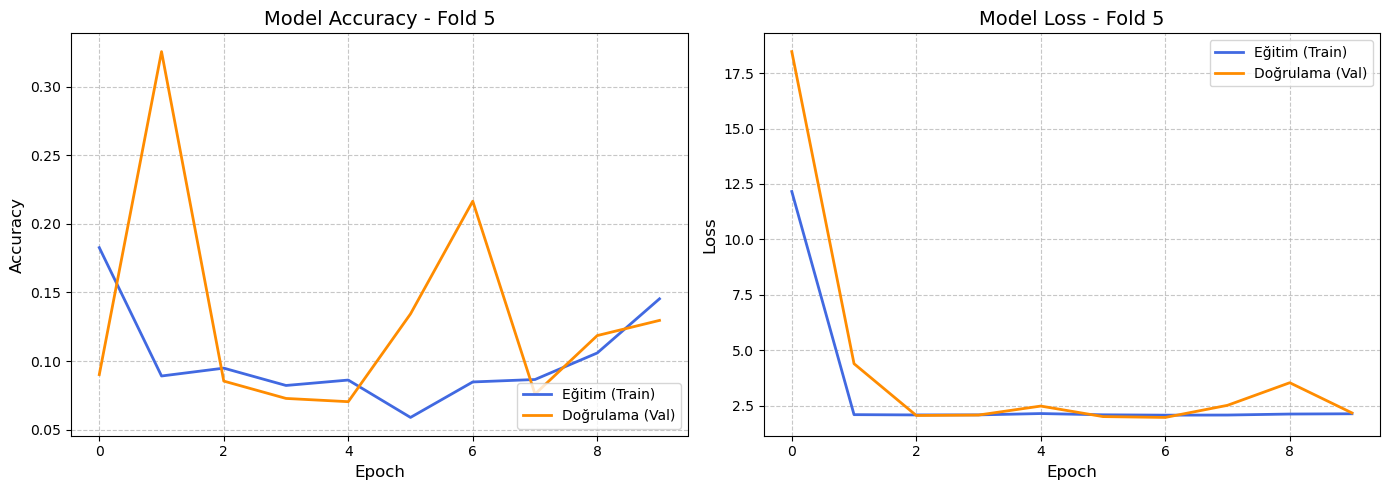

In [ ]:
val_accuracies = [max(h.history['val_accuracy']) for h in fold_histories]


for i in range(5):
    print(f"Fold {i+1} - En İyi Val Accuracy: %{val_accuracies[i]*100:.2f}")

mean_acc = np.mean(val_accuracies) * 100
std_acc = np.std(val_accuracies) * 100
print(f"\nGenel Ortalama Doğruluk (Mean CV Accuracy): %{mean_acc:.2f} (± %{std_acc:.2f})")

plt.figure(figsize=(14, 5))

# 1. Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(fold_histories[-1].history['accuracy'], label='Eğitim (Train)', linewidth=2, color='royalblue')
plt.plot(fold_histories[-1].history['val_accuracy'], label='Doğrulama (Val)', linewidth=2, color='darkorange')
plt.title('Model Accuracy - Fold 5', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Hata (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(fold_histories[-1].history['loss'], label='Eğitim (Train)', linewidth=2, color='royalblue')
plt.plot(fold_histories[-1].history['val_loss'], label='Doğrulama (Val)', linewidth=2, color='darkorange')
plt.title('Model Loss - Fold 5', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The accuracy and loss graphs clearly indicate that the baseline model suffered from underfitting . Both the training and validation accuracy plateaued at suboptimal levels early in the process, while the loss values failed to converge significantly.

<font color = 'green'>
<a id ="10"></a>

* ### Improved Model

In this model, we used successive Conv2D + BatchNormalization + MaxPooling2D layers to extract features from the input images. As the network gets deeper, it can learn more complex patterns and visual details. After that, the Flatten layer converts the feature maps into a vector, and the Dense layer performs the final classification. We also used Dropout to reduce overfitting and a softmax output layer to produce probabilities for the 8 classes.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

def create_improved_model():
    model = Sequential([
        # 1. Blok
        Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224, 224, 3)),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # 2. Blok
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # 3. Blok
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(256, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),

        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.4), 
        
        Dense(8, activation='softmax') 
    ])

    optimizer = Adam(learning_rate=0.0001)
    
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
                  
    return model

improved_model = create_improved_model()
improved_model.summary()

c:\Users\avcie\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_92 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_111         │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_92 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_112         │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_93 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_113         │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_94 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_114         │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_95 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_115         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,087,112 (99.51 MB)

 Trainable params: 26,085,128 (99.51 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

EPOCHS = 20 
fold_histories = [] 

for fold in range(5):
    print(f"\n{'='*50}\n Yeni model ile fold {fold+1} egitimi basliyor\n{'='*50}")

    train_df = df_train_val[df_train_val['fold'] != fold]
    val_df = df_train_val[df_train_val['fold'] == fold]

    train_datagen = ImageDataGenerator(
        rescale=1./255.,
        rotation_range=20,      
        horizontal_flip=True,   
        vertical_flip=True      
    )
    val_datagen = ImageDataGenerator(rescale=1./255.)


    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df, x_col="image_path", y_col="label",
        target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", shuffle=True
    )

    val_generator = val_datagen.flow_from_dataframe(
        dataframe=val_df, x_col="image_path", y_col="label",
        target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", shuffle=False
    )



    early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001, verbose=1)

    history = improved_model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=val_generator,
        class_weight=class_weights_dict, 
        callbacks=[early_stop, reduce_lr], 
        verbose=1
    )

    fold_histories.append(history)
    

print("\nYeni model ile egitim bitti.")


 Yeni model ile fold 1 egitimi basliyor
Found 5061 validated image filenames belonging to 8 classes.
Found 1266 validated image filenames belonging to 8 classes.
Epoch 1/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.3827 - loss: 1.7029 - val_accuracy: 0.1027 - val_loss: 6.2978 - learning_rate: 1.0000e-04
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 408s 3s/step - accuracy: 0.4622 - loss: 1.4402 - val_accuracy: 0.4265 - val_loss: 5.8535 - learning_rate: 1.0000e-04
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 407s 3s/step - accuracy: 0.4954 - loss: 1.2972 - val_accuracy: 0.4100 - val_loss: 1.8973 - learning_rate: 1.0000e-04
Epoch 4/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 404s 3s/step - accuracy: 0.5293 - loss: 1.2121 - val_accuracy: 0.4905 - val_loss: 1.3480 - learning_rate: 1.0000e-04
Epoch 5/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.5469 - loss: 1.1008 - val_accuracy: 0.4005 - val_loss: 1.8961 - learning_rate: 1.0000e-04
Epoch 6/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step -

* Accuracy Loss Graphs

--- YENİ MODEL: 5-Fold Cross Validation Sonuçlari ---
Fold 1 - En İyi Val Accuracy: %72.51
Fold 2 - En İyi Val Accuracy: %78.52
Fold 3 - En İyi Val Accuracy: %78.50
Fold 4 - En İyi Val Accuracy: %77.63
Fold 5 - En İyi Val Accuracy: %80.08

🚀 Yeni Genel Ortalama Doğruluk (Mean CV Accuracy): %77.45 (± %2.59)


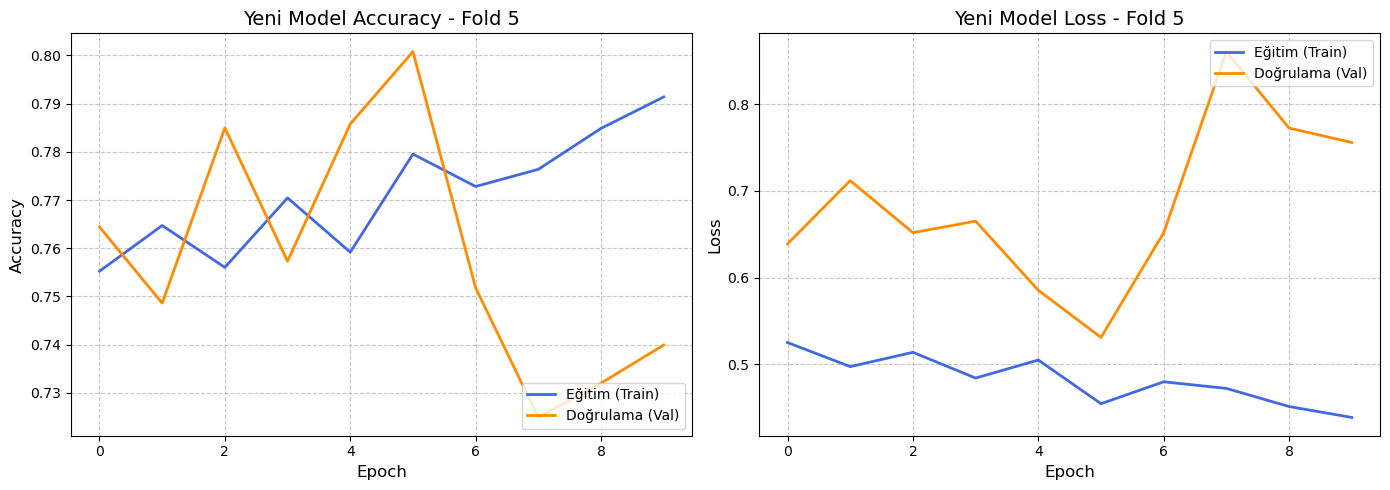

In [ ]:
print("--- YENİ MODEL: 5-Fold Cross Validation Sonuçlari ---")

val_accuracies = [max(h.history['val_accuracy']) for h in fold_histories]

for i in range(5):
    print(f"Fold {i+1} - En İyi Val Accuracy: %{val_accuracies[i]*100:.2f}")


mean_acc = np.mean(val_accuracies) * 100
std_acc = np.std(val_accuracies) * 100
print(f"\n Yeni Genel Ortalama Doğruluk (Mean CV Accuracy): %{mean_acc:.2f} (± %{std_acc:.2f})")

plt.figure(figsize=(14, 5))

# 1. Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(fold_histories[-1].history['accuracy'], label='Eğitim (Train)', linewidth=2, color='royalblue')
plt.plot(fold_histories[-1].history['val_accuracy'], label='Doğrulama (Val)', linewidth=2, color='darkorange')
plt.title('Yeni Model Accuracy - Fold 5', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Hata (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(fold_histories[-1].history['loss'], label='Eğitim (Train)', linewidth=2, color='royalblue')
plt.plot(fold_histories[-1].history['val_loss'], label='Doğrulama (Val)', linewidth=2, color='darkorange')
plt.title('Yeni Model Loss - Fold 5', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Compared to the previous model, the improved model produced better overall results. Although a certain degree of overfitting was observed, it achieved an accuracy of around 75%, making it the most successful CNN model in this study.

🚀 Test Seti Jeneratörü Hazırlanıyor...
Found 1582 validated image filenames belonging to 8 classes.

--- 1. GENEL TEST BAŞARISI (FINAL SCORE) ---
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 614ms/step - accuracy: 0.7491 - loss: 0.7205
✅ Final Test Accuracy: %74.91
✅ Final Test Loss: 0.7205

--- 2. DETAYLI TAHMİNLER YAPILIYOR (Bu biraz sürebilir) ---
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 659ms/step

SINIFLANDIRMA RAPORU (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

     SOB_B_A       0.75      0.92      0.83        89
     SOB_B_F       0.79      0.77      0.78       203
    SOB_B_PT       0.71      0.66      0.69        91
    SOB_B_TA       0.63      0.87      0.73       114
    SOB_M_DC       0.93      0.73      0.82       690
    SOB_M_LC       0.59      0.74      0.66       125
    SOB_M_MC       0.71      0.62      0.66       158
    SOB_M_PC       0.47      0.80      0.59       112

    accuracy                           0.75      1582
   macro avg       0.70      0.

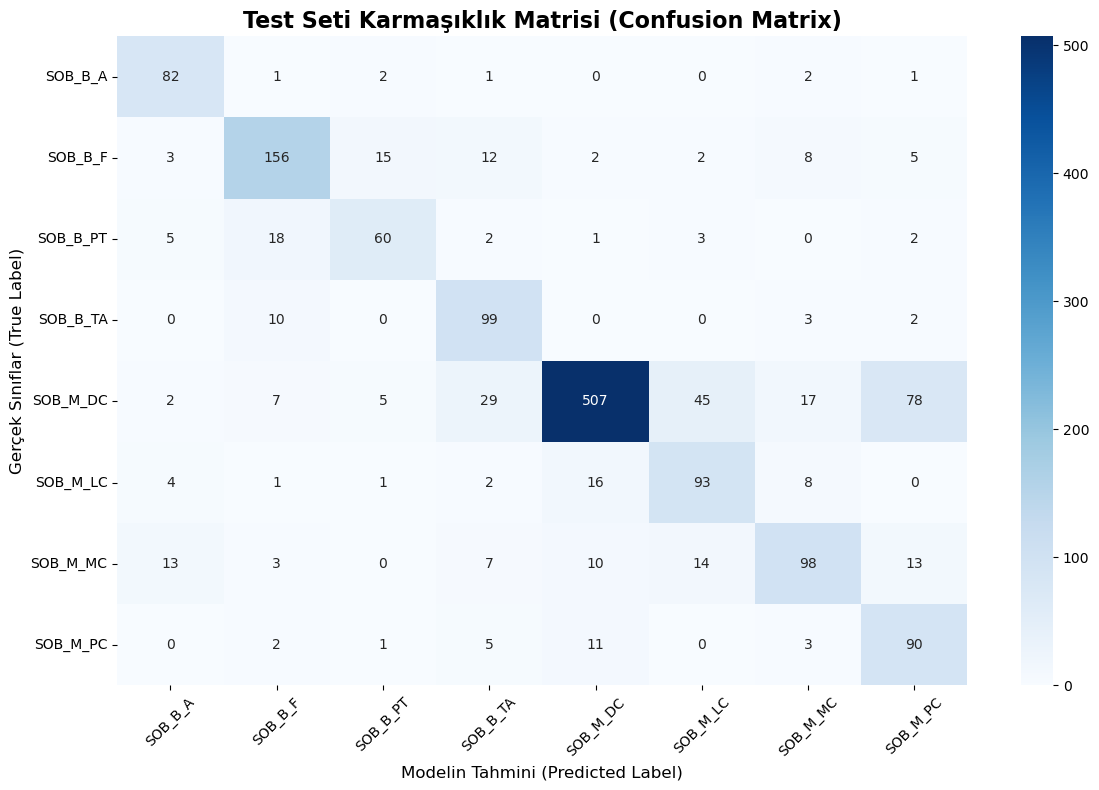

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255.)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col="image_path",
    y_col="label",
    target_size=TARGET_SIZE, 
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False # ÇOK ÖNEMLİ: Sırayı asla bozmuyoruz ki gerçek cevaplarla eşleştirebilelim!
)

print("\n--- FINAL SCORE ---")
test_loss, test_acc = improved_model.evaluate(test_generator, verbose=1)
print(f"✅ Final Test Accuracy: %{test_acc*100:.2f}")
print(f"✅ Final Test Loss: {test_loss:.4f}")

test_generator.reset() # Jeneratörü garanti olsun diye başa sarıyoruz
predictions = improved_model.predict(test_generator, verbose=1)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("\n" + "="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(12, 8))
# Şık bir ısı haritası çizdiriyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<font color = 'green'>
<a id ="11"></a>

* ### GAP Model

In this section, Global Average Pooling (GAP) was also tested in order to reduce the overfitting problem.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def create_ultimate_model():
    model_ult = Sequential([
       
        Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224, 224, 3)),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(256, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        GlobalAveragePooling2D(),
        
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4), 
        
        Dense(8, activation='softmax') 
    ])
    
    optimizer_ultimate = Adam(learning_rate=0.0001)
    model_ult.compile(optimizer=optimizer_ultimate, loss='categorical_crossentropy', metrics=['accuracy'])
    return model_ult

EPOCHS_ULTIMATE = 25 
fold_histories_ultimate = [] 

for fold in range(5):
    print(f"\n{'='*50}\n Final model fold {fold+1}.\n{'='*50}")

    train_df_ultimate = df_train_val[df_train_val['fold'] != fold]
    val_df_ultimate = df_train_val[df_train_val['fold'] == fold]

    train_datagen_ultimate = ImageDataGenerator(
        rescale=1./255.,
        rotation_range=20,      
        horizontal_flip=True,   
        vertical_flip=True      
    )
    val_datagen_ultimate = ImageDataGenerator(rescale=1./255.)

    train_generator_ultimate = train_datagen_ultimate.flow_from_dataframe(
        dataframe=train_df_ultimate, x_col="image_path", y_col="label",
        target_size=TARGET_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=True
    )

    val_generator_ultimate = val_datagen_ultimate.flow_from_dataframe(
        dataframe=val_df_ultimate, x_col="image_path", y_col="label",
        target_size=TARGET_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
    )

    ultimate_model = create_ultimate_model()

    early_stop_ultimate = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
    reduce_lr_ultimate = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001, verbose=1)

    history_ultimate = ultimate_model.fit(
        train_generator_ultimate,
        epochs=EPOCHS_ULTIMATE,
        validation_data=val_generator_ultimate,
        class_weight=class_weights_dict, 
        callbacks=[early_stop_ultimate, reduce_lr_ultimate],
        verbose=1
    )

    fold_histories_ultimate.append(history_ultimate)
    print(f"\n✅ Fold {fold+1} Bitti!")

print("\n final model egitimi tamamlandi")


 Final model fold 1.
Found 5061 validated image filenames belonging to 8 classes.
Found 1266 validated image filenames belonging to 8 classes.


c:\Users\avcie\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 663s 4s/step - accuracy: 0.3142 - loss: 1.9186 - val_accuracy: 0.0853 - val_loss: 2.2335 - learning_rate: 1.0000e-04
Epoch 2/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 642s 4s/step - accuracy: 0.3940 - loss: 1.6177 - val_accuracy: 0.1445 - val_loss: 3.1397 - learning_rate: 1.0000e-04
Epoch 3/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 630s 4s/step - accuracy: 0.4505 - loss: 1.4526 - val_accuracy: 0.3215 - val_loss: 2.0038 - learning_rate: 1.0000e-04
Epoch 4/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 637s 4s/step - accuracy: 0.4878 - loss: 1.3768 - val_accuracy: 0.4510 - val_loss: 1.4349 - learning_rate: 1.0000e-04
Epoch 5/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 643s 4s/step - accuracy: 0.4918 - loss: 1.2630 - val_accuracy: 0.4755 - val_loss: 1.5342 - learning_rate: 1.0000e-04
Epoch 6/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 646s 4s/step - accuracy: 0.5181 - loss: 1.2027 - val_accuracy: 0.5087 - val_loss: 1.3922 - learning_rate: 1.0000e-04
Epoch 7/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 641s 4s/step - acc

c:\Users\avcie\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 664s 4s/step - accuracy: 0.3553 - loss: 1.8319 - val_accuracy: 0.0742 - val_loss: 2.3862 - learning_rate: 1.0000e-04
Epoch 2/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 653s 4s/step - accuracy: 0.4215 - loss: 1.5307 - val_accuracy: 0.1035 - val_loss: 3.1373 - learning_rate: 1.0000e-04
Epoch 3/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4657 - loss: 1.4011
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
159/159 ━━━━━━━━━━━━━━━━━━━━ 648s 4s/step - accuracy: 0.4554 - loss: 1.4300 - val_accuracy: 0.2512 - val_loss: 2.4151 - learning_rate: 1.0000e-04
Epoch 4/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 646s 4s/step - accuracy: 0.5210 - loss: 1.2691 - val_accuracy: 0.5671 - val_loss: 1.1968 - learning_rate: 5.0000e-05
Epoch 5/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 641s 4s/step - accuracy: 0.5208 - loss: 1.1990 - val_accuracy: 0.5648 - val_loss: 1.2290 - learning_rate: 5.0000e-05
Epoch 6/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 643s 4s/step - accuracy: 

...

Epoch 1/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 660s 4s/step - accuracy: 0.3481 - loss: 1.8442 - val_accuracy: 0.0838 - val_loss: 2.2506 - learning_rate: 1.0000e-04
Epoch 2/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 642s 4s/step - accuracy: 0.4249 - loss: 1.5471 - val_accuracy: 0.4047 - val_loss: 2.2729 - learning_rate: 1.0000e-04
Epoch 3/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 641s 4s/step - accuracy: 0.4591 - loss: 1.4388 - val_accuracy: 0.3470 - val_loss: 2.2059 - learning_rate: 1.0000e-04
Epoch 4/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 637s 4s/step - accuracy: 0.5055 - loss: 1.2815 - val_accuracy: 0.4237 - val_loss: 1.6711 - learning_rate: 1.0000e-04
Epoch 5/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 638s 4s/step - accuracy: 0.5154 - loss: 1.2284 - val_accuracy: 0.4680 - val_loss: 1.3916 - learning_rate: 1.0000e-04
Epoch 6/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 642s 4s/step - accuracy: 0.5486 - loss: 1.1446 - val_accuracy: 0.4885 - val_loss: 1.7176 - learning_rate: 1.0000e-04
Epoch 7/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 644s 4s/step - acc

c:\Users\avcie\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 654s 4s/step - accuracy: 0.3552 - loss: 1.8926 - val_accuracy: 0.3202 - val_loss: 1.9236 - learning_rate: 1.0000e-04
Epoch 2/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 645s 4s/step - accuracy: 0.4281 - loss: 1.5442 - val_accuracy: 0.2079 - val_loss: 2.5431 - learning_rate: 1.0000e-04
Epoch 3/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4537 - loss: 1.4543
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
159/159 ━━━━━━━━━━━━━━━━━━━━ 645s 4s/step - accuracy: 0.4617 - loss: 1.4294 - val_accuracy: 0.3644 - val_loss: 2.3545 - learning_rate: 1.0000e-04
Epoch 4/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 638s 4s/step - accuracy: 0.4949 - loss: 1.2851 - val_accuracy: 0.5549 - val_loss: 1.2331 - learning_rate: 5.0000e-05
Epoch 5/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 640s 4s/step - accuracy: 0.5207 - loss: 1.2125 - val_accuracy: 0.5755 - val_loss: 1.1863 - learning_rate: 5.0000e-05
Epoch 6/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 642s 4s/step - accuracy: 

c:\Users\avcie\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 650s 4s/step - accuracy: 0.3520 - loss: 1.8570 - val_accuracy: 0.0791 - val_loss: 2.1666 - learning_rate: 1.0000e-04
Epoch 2/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 641s 4s/step - accuracy: 0.4273 - loss: 1.5336 - val_accuracy: 0.0822 - val_loss: 3.6572 - learning_rate: 1.0000e-04
Epoch 3/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 642s 4s/step - accuracy: 0.4478 - loss: 1.4445 - val_accuracy: 0.3375 - val_loss: 2.0821 - learning_rate: 1.0000e-04
Epoch 4/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 639s 4s/step - accuracy: 0.4648 - loss: 1.3894 - val_accuracy: 0.4767 - val_loss: 1.3758 - learning_rate: 1.0000e-04
Epoch 5/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 637s 4s/step - accuracy: 0.5053 - loss: 1.2765 - val_accuracy: 0.5937 - val_loss: 1.0636 - learning_rate: 1.0000e-04
Epoch 6/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 642s 4s/step - accuracy: 0.5122 - loss: 1.2302 - val_accuracy: 0.4593 - val_loss: 1.4706 - learning_rate: 1.0000e-04
Epoch 7/25
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accur

The main reason why the accuracy dropped to around 65% in the model using Global Average Pooling (GAP) is that the GAP layer compresses the feature maps much more aggressively, which may cause the model to lose some fine discriminative details. In histopathological images, the differences between classes are often subtle and depend on local patterns, so this strong summarization may have reduced the model’s ability to distinguish between classes effectively. In addition, the stronger data augmentation techniques used in this model, especially vertical flipping and higher rotation, may have made the training process more difficult. As a result, although GAP is useful for reducing overfitting, in this dataset it likely reduced the representational capacity of the model, leading to lower accuracy compared to the previous improved model.

Final model results 
Fold 1 - En İyi Val Accuracy: %66.51
Fold 2 - En İyi Val Accuracy: %67.54
Fold 3 - En İyi Val Accuracy: %70.12
Fold 4 - En İyi Val Accuracy: %58.26
Fold 5 - En İyi Val Accuracy: %66.88

 Ultimate Ortalama Doğruluk: %65.86 (± %4.00)


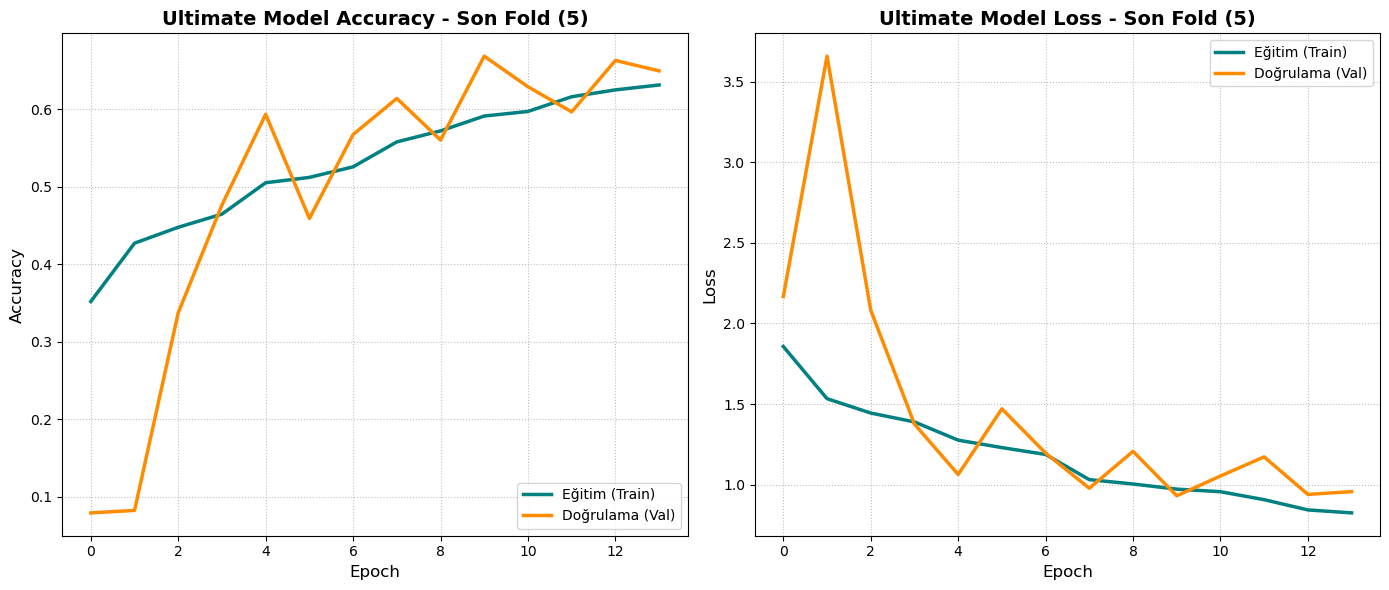

In [ ]:
print("Final model results ")

val_accuracies_ultimate = [max(h.history['val_accuracy']) for h in fold_histories_ultimate]

for i in range(len(val_accuracies_ultimate)):
    print(f"Fold {i+1} - En İyi Val Accuracy: %{val_accuracies_ultimate[i]*100:.2f}")

mean_acc_ult = np.mean(val_accuracies_ultimate) * 100
std_acc_ult = np.std(val_accuracies_ultimate) * 100
print(f"\n Ultimate Ortalama Doğruluk: %{mean_acc_ult:.2f} (± %{std_acc_ult:.2f})")

if len(fold_histories_ultimate) > 0:
    plt.figure(figsize=(14, 6))

    color_train = 'teal'
    color_val = 'darkorange'

    # 1. Doğruluk (Accuracy) Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(fold_histories_ultimate[-1].history['accuracy'], label='Eğitim (Train)', linewidth=2.5, color=color_train)
    plt.plot(fold_histories_ultimate[-1].history['val_accuracy'], label='Doğrulama (Val)', linewidth=2.5, color=color_val)
    plt.title(f'Ultimate Model Accuracy - Son Fold ({len(fold_histories_ultimate)})', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.8)

    # 2. Hata (Loss) Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(fold_histories_ultimate[-1].history['loss'], label='Eğitim (Train)', linewidth=2.5, color=color_train)
    plt.plot(fold_histories_ultimate[-1].history['val_loss'], label='Doğrulama (Val)', linewidth=2.5, color=color_val)
    plt.title(f'Ultimate Model Loss - Son Fold ({len(fold_histories_ultimate)})', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.8)

    plt.tight_layout()
    plt.show()
else:
    print("error")

<font color = 'red'>
<a id ="7"></a>


## DenseNet121 Models

A different data splitting and loading strategy was applied for the DenseNet121 model. The main reason for this was that the test set from the previous split had already been used to evaluate the best CNN model. Therefore, in order to ensure a fairer and more reliable comparison and to avoid any indirect dependence on the previous test set, a separate data split and loading pipeline was used for the DenseNet121 experiment.

In [14]:
ROOT_DIR = r"C:\Users\avcie\Desktop\DL homework\BreaKHis_v1\histology_slides\breast"

all_image_paths = glob.glob(os.path.join(ROOT_DIR, "**", "*.png"), recursive=True)

print(f"Toplam bulunan goruntu sayisi: {len(all_image_paths)}")


def parse_breakhis_path(path):
    path_norm = os.path.normpath(path)
    parts = path_norm.split(os.sep)

    filename = parts[-1]                 
    magnification_folder = parts[-2]     
    case_folder = parts[-3]              
    subtype_folder = parts[-4]           
    binary_label = parts[-6].lower()     

    filename_wo_ext = os.path.splitext(filename)[0]

    pattern = r'^(SOB_[BM]_[A-Z]+)-([0-9]+-[A-Z0-9]+)-([0-9]+)-([0-9]+)$'
    match = re.match(pattern, filename_wo_ext)

    if match is None:
        return None

    class_code = match.group(1)              
    patient_case = match.group(2)            
    magnification_file = match.group(3)      
    patch_id = match.group(4)                

    magnification_folder_num = magnification_folder.replace("X", "")

    if magnification_folder_num != magnification_file:
        return None

    return {
        "image_path": path,
        "label": class_code,                
        "binary_label": binary_label,        
        "subtype": subtype_folder,           
        "patient_id": patient_case,         
        "case_folder": case_folder,         
        "magnification": int(magnification_file),
        "patch_id": int(patch_id)
    }

records = []

for path in all_image_paths:
    parsed = parse_breakhis_path(path)
    if parsed is not None:
        records.append(parsed)

df = pd.DataFrame(records)


print("\nDataFrame oluşturuldu.")
print(df.head())

print("\nShape:", df.shape)

print("\nSutunlar:")
print(df.columns.tolist())

print("\n8-class dagilimi:")
print(df["label"].value_counts())

print("\nBinary dagilimi:")
print(df["binary_label"].value_counts())

print("\nMagnification dagilimi:")
print(df["magnification"].value_counts().sort_index())

print("\nBenzersiz patient sayisi:")
print(df["patient_id"].nunique())

Toplam bulunan goruntu sayisi: 7909

DataFrame oluşturuldu.
                                          image_path    label binary_label  \
0  C:\Users\avcie\Desktop\DL homework\BreaKHis_v1...  SOB_B_A       benign   
1  C:\Users\avcie\Desktop\DL homework\BreaKHis_v1...  SOB_B_A       benign   
2  C:\Users\avcie\Desktop\DL homework\BreaKHis_v1...  SOB_B_A       benign   
3  C:\Users\avcie\Desktop\DL homework\BreaKHis_v1...  SOB_B_A       benign   
4  C:\Users\avcie\Desktop\DL homework\BreaKHis_v1...  SOB_B_A       benign   

    subtype  patient_id         case_folder  magnification  patch_id  
0  adenosis  14-22549AB  SOB_B_A_14-22549AB            100         1  
1  adenosis  14-22549AB  SOB_B_A_14-22549AB            100         2  
2  adenosis  14-22549AB  SOB_B_A_14-22549AB            100         3  
3  adenosis  14-22549AB  SOB_B_A_14-22549AB            100         4  
4  adenosis  14-22549AB  SOB_B_A_14-22549AB            100         5  

Shape: (7909, 8)

Sutunlar:
['image_path', '

In [15]:
from sklearn.model_selection import train_test_split

df_train_val, df_test = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.20,
    stratify=df_train_val["label"],
    random_state=42
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(df_train["label"].value_counts())
print(df_val["label"].value_counts())
print(df_test["label"].value_counts())

label
SOB_M_DC    2208
SOB_B_F      649
SOB_M_MC     507
SOB_M_LC     401
SOB_B_TA     364
SOB_M_PC     358
SOB_B_PT     290
SOB_B_A      284
Name: count, dtype: int64
label
SOB_M_DC    553
SOB_B_F     162
SOB_M_MC    127
SOB_M_LC    100
SOB_B_TA     91
SOB_M_PC     90
SOB_B_PT     72
SOB_B_A      71
Name: count, dtype: int64
label
SOB_M_DC    690
SOB_B_F     203
SOB_M_MC    158
SOB_M_LC    125
SOB_B_TA    114
SOB_M_PC    112
SOB_B_PT     91
SOB_B_A      89
Name: count, dtype: int64


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input
from tensorflow.keras import layers, models

TARGET_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 8
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

ALL_CLASSES = ["SOB_B_A", "SOB_B_F", "SOB_B_PT", "SOB_B_TA",
               "SOB_M_DC", "SOB_M_LC", "SOB_M_MC", "SOB_M_PC"]

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col="image_path",
    y_col="label",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=ALL_CLASSES,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col="image_path",
    y_col="label",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=ALL_CLASSES,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col="image_path",
    y_col="label",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=ALL_CLASSES,
    shuffle=False
)

train_labels = df_train["label"].values
unique_classes = np.sort(np.unique(train_labels))

weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=train_labels
)

class_indices = train_generator.class_indices
class_weights_dict = {
    class_indices[class_name]: float(weight)
    for class_name, weight in zip(unique_classes, weights)
}

print("Class indices:", class_indices)
print("Class weights:", class_weights_dict)

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=callbacks1,
    verbose=1
)

base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    class_weight=class_weights_dict,
    callbacks=callbacks2,
    verbose=1
)

test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print(f"\nBest Stage 1 Val Accuracy: {max(history1.history['val_accuracy']):.4f}")
print(f"Best Stage 2 Val Accuracy: {max(history2.history['val_accuracy']):.4f}")
print(f"Final Test Accuracy      : {test_acc:.4f}")

Found 5061 validated image filenames belonging to 8 classes.
Found 1266 validated image filenames belonging to 8 classes.
Found 1582 validated image filenames belonging to 8 classes.
Class indices: {'SOB_B_A': 0, 'SOB_B_F': 1, 'SOB_B_PT': 2, 'SOB_B_TA': 3, 'SOB_M_DC': 4, 'SOB_M_LC': 5, 'SOB_M_MC': 6, 'SOB_M_PC': 7}
Class weights: {0: 2.2275528169014085, 1: 0.974768875192604, 2: 2.1814655172413793, 3: 1.7379807692307692, 4: 0.2865149456521739, 5: 1.5776184538653366, 6: 1.2477810650887573, 7: 1.767108938547486}
Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 664s 4s/step - accuracy: 0.3608 - loss: 1.7621 - val_accuracy: 0.5229 - val_loss: 1.3552 - learning_rate: 3.0000e-04
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 666s 4s/step - accuracy: 0.5289 - loss: 1.1775 - val_accuracy: 0.5948 - val_loss: 1.1342 - learning_rate: 3.0000e-04
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 646s 4s/step - accuracy: 0.5738 - loss: 1.0218 - val_accuracy: 0.6438 - val_loss: 0.9544 - learning_rate: 3.0000e-04
Epoch 4/10
159

The results show that the initial DenseNet model performed better before fine-tuning. This indicates that the fine-tuning process may have negatively affected the learned representations, leading to a decrease in accuracy from 74% to 71%.